# 文件: chart_16_1.py

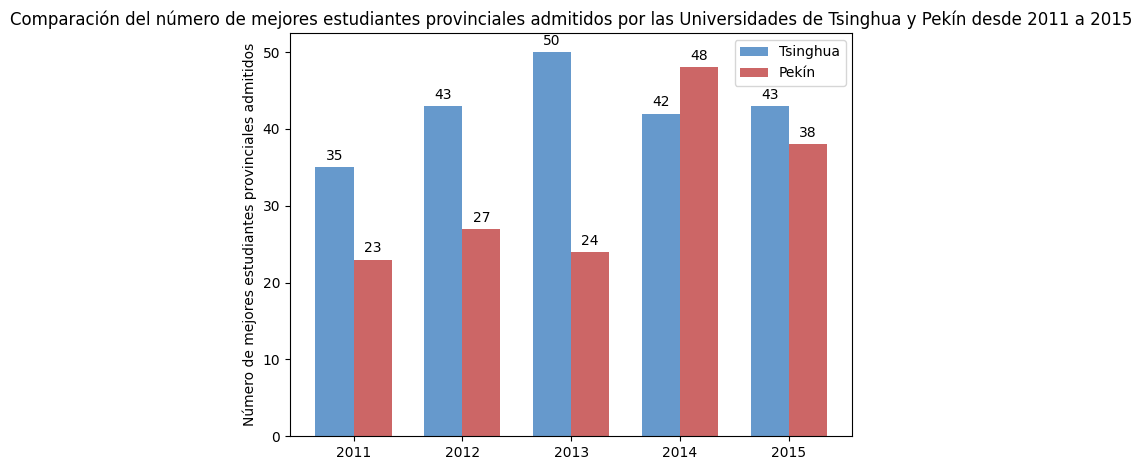

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Años
años = [2011, 2012, 2013, 2014, 2015]
# Número de mejores estudiantes provinciales admitidos por la Universidad de Tsinghua
qinghua = [35, 43, 50, 42, 43]
# Número de mejores estudiantes provinciales admitidos por la Universidad de Pekín
beida = [23, 27, 24, 48, 38]

# Establecer el ancho de las barras
ancho_barra = 0.35
# Generar posiciones en el eje x para los dos grupos de barras
x = np.arange(len(años))

# Crear una figura y ejes
fig, ax = plt.subplots()

# Dibujar las barras para la Universidad de Tsinghua
rects1 = ax.bar(x - ancho_barra/2, qinghua, ancho_barra, label='Tsinghua', color='#6699CC')
# Dibujar las barras para la Universidad de Pekín
rects2 = ax.bar(x + ancho_barra/2, beida, ancho_barra, label='Pekín', color='#CC6666')

# Establecer las marcas y etiquetas del eje x
ax.set_xticks(x)
ax.set_xticklabels(años)
# Establecer la etiqueta del eje y
ax.set_ylabel('Número de mejores estudiantes provinciales admitidos')
# Establecer el título
ax.set_title('Comparación del número de mejores estudiantes provinciales admitidos por las Universidades de Tsinghua y Pekín desde 2011 a 2015')
# Agregar una leyenda
ax.legend()

# Etiquetar los valores en las barras
def autolabel(rects):
    for rect in rects:
        altura = rect.get_height()
        ax.annotate('{}'.format(altura),
                    xy=(rect.get_x() + rect.get_width() / 2, altura),
                    xytext=(0, 3),  # Desplazamiento vertical de 3 puntos
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

# Ajustar el diseño para evitar la superposición de etiquetas
fig.tight_layout()
# Mostrar el gráfico
plt.show()

# 文件: chart_16_2.py

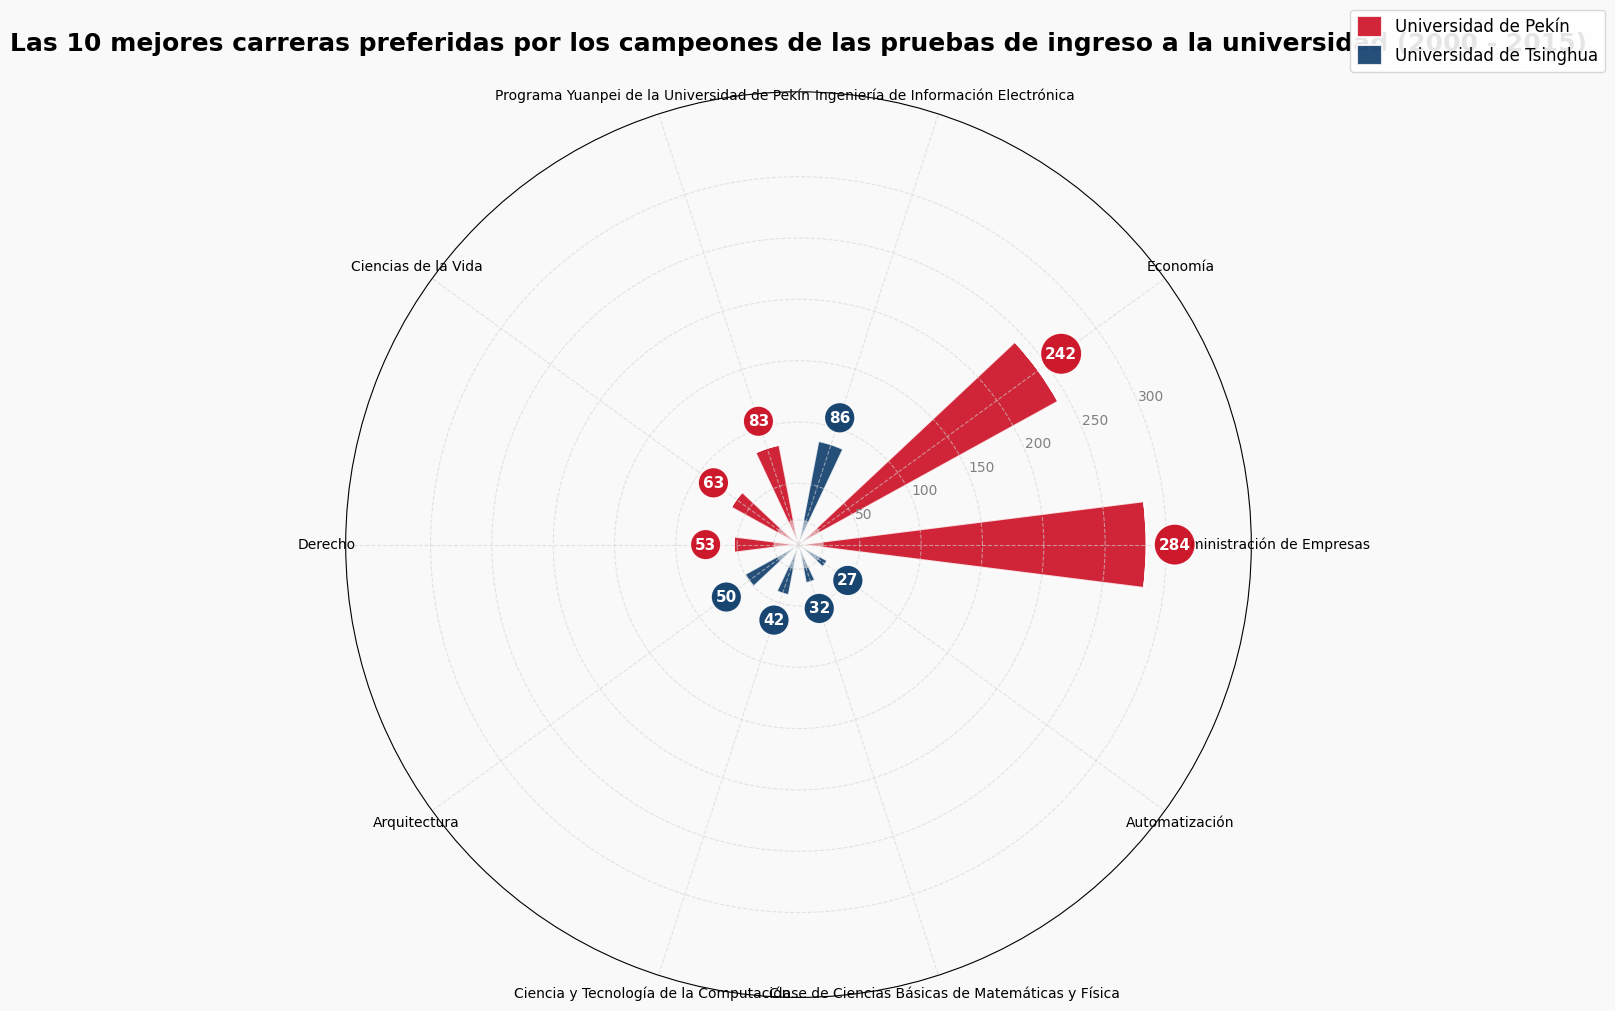

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle
from matplotlib.colors import LinearSegmentedColormap

# Lista de nombres de carreras
carreras = [
    "Administración de Empresas", "Economía", "Ingeniería de Información Electrónica", "Programa Yuanpei de la Universidad de Pekín",
    "Ciencias de la Vida", "Derecho", "Arquitectura", "Ciencia y Tecnología de la Computación",
    "Clase de Ciencias Básicas de Matemáticas y Física", "Automatización"
]
# Datos de la Universidad de Pekín y la Universidad de Tsinghua (en orden de carrera)
datos_pku = [284, 242, 0, 83, 63, 53, 0, 0, 0, 0]
datos_tsinghua = [0, 0, 86, 0, 0, 0, 50, 42, 32, 27]

# Calcular ángulos en coordenadas polares, cada carrera corresponde a un ángulo
angulos = np.linspace(0, 2 * np.pi, len(carreras), endpoint=False).tolist()
angulos += angulos[:1]  # Cerrar la figura

# Crear un esquema de colores personalizado
color_pku = '#C90016'  # Rojo de la Universidad de Pekín
color_th = '#003162'   # Azul de la Universidad de Tsinghua
color_fondo = '#F9F9F9'   # Color de fondo

# Crear el lienzo y la subfigura en coordenadas polares
fig = plt.figure(figsize=(14, 14), facecolor=color_fondo)  # Aumentar el tamaño del lienzo
ax = plt.subplot(111, polar=True, facecolor=color_fondo)

# Dibujar el gráfico de barras de los datos de la Universidad de Pekín
barras_pku = ax.bar(
    angulos[:-1], datos_pku, width=0.25,
    color=color_pku, alpha=0.85,
    edgecolor='white', linewidth=1.5,
    label='Universidad de Pekín'
)

# Dibujar el gráfico de barras de los datos de la Universidad de Tsinghua
barras_tsinghua = ax.bar(
    angulos[:-1], datos_tsinghua, width=0.25,
    color=color_th, alpha=0.85,
    edgecolor='white', linewidth=1.5,
    bottom=datos_pku, label='Universidad de Tsinghua'
)

# Configurar el estilo de las líneas de la cuadrícula
ax.grid(True, color='lightgray', linestyle='--', alpha=0.6)

# Configurar las etiquetas polares (nombres de las carreras)
ax.set_thetagrids(np.degrees(angulos[:-1]), carreras)
plt.setp(ax.get_xticklabels(), fontsize=10, weight='medium')  # Reducir el tamaño de la fuente

# Configurar las divisiones radiales (ocultar las divisiones predeterminadas y mostrar personalizadas)
valor_maximo = max([p + t for p, t in zip(datos_pku, datos_tsinghua)])
ax.set_ylim(0, valor_maximo * 1.3)  # Aumentar el límite superior para dejar más espacio para las etiquetas
ax.set_rticks([50, 100, 150, 200, 250, 300])
plt.setp(ax.get_yticklabels(), fontsize=10, color='gray')

# Configurar el título
plt.title("Las 10 mejores carreras preferidas por los campeones de las pruebas de ingreso a la universidad (2000 - 2015)",
          fontsize=18, fontweight='bold', pad=30)

# Calcular inteligentemente la posición de las etiquetas para evitar superposiciones
posiciones_etiquetas = {}  # Almacenar la posición de las etiquetas de cada ángulo

for i, (angulo, valor_pku, valor_th) in enumerate(zip(angulos[:-1], datos_pku, datos_tsinghua)):
    altura_total = valor_pku + valor_th
    
    # Calcular el desplazamiento base
    desplazamiento_base = valor_maximo * 0.08
    
    # Verificar si hay otras etiquetas cerca del ángulo actual
    angulos_conflicto = [a for a in posiciones_etiquetas.keys() 
                      if abs(a - angulo) < 0.3 or abs(a - angulo) > 2 * np.pi - 0.3]
    
    # Si hay conflicto, aumentar el desplazamiento
    if angulos_conflicto:
        desplazamiento_maximo = max(posiciones_etiquetas[a] for a in angulos_conflicto)
        desplazamiento = desplazamiento_maximo + desplazamiento_base * 1.5  # Aumentar más el espaciado
    else:
        desplazamiento = desplazamiento_base
    
    # Etiqueta de la Universidad de Pekín
    if valor_pku > 0:
        r_etiqueta = valor_pku + desplazamiento
        ax.annotate(
            f"{valor_pku}",
            xy=(angulo, valor_pku),
            xytext=(angulo, r_etiqueta),
            textcoords='data',
            ha='center', va='center',
            color='white', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle="circle,pad=0.3", fc=color_pku, ec='white', alpha=0.9)
        )
        posiciones_etiquetas[angulo] = r_etiqueta
    
    # Etiqueta de la Universidad de Tsinghua
    if valor_th > 0:
        r_etiqueta = altura_total + desplazamiento
        ax.annotate(
            f"{valor_th}",
            xy=(angulo, altura_total),
            xytext=(angulo, r_etiqueta),
            textcoords='data',
            ha='center', va='center',
            color='white', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle="circle,pad=0.3", fc=color_th, ec='white', alpha=0.9)
        )
        posiciones_etiquetas[angulo] = r_etiqueta

# Leyenda personalizada
leyenda = ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.4, 1.1),
    frameon=True,
    framealpha=0.9,
    edgecolor='lightgray',
    fontsize=12,
    markerscale=1.2,
    handlelength=1.5,
    handleheight=1.5
)
marco = leyenda.get_frame()
marco.set_facecolor('white')

# Agregar un círculo central
circulo_centro = Circle((0, 0), 20, transform=ax.transData._b,
                       facecolor=color_fondo, edgecolor='lightgray', linestyle='--', alpha=0.5)
ax.add_artist(circulo_centro)

# Ajustar el diseño
plt.tight_layout()
plt.subplots_adjust(top=0.85)

# Mostrar el gráfico
plt.show()